# Sprawozdanie: Dwuosobowe gry deterministyczne (Nim Misère)

## I. Wstęp i metodologia eksperymentów
Analizowana gra to **Nim Misère** (wariant gry Nim, w którym przegrywa gracz zabierający ostatni żeton) dla $K=3$, gdzie liczba początkowych żetonów spełnia $N \in [8, 20]$.

Konfiguracja eksperymentów:
- głębokości przeszukiwania: $d \in \{2, 3, 4, 5\}$,
- 200 partii dla każdego wariantu i każdej głębokości,
- przeciwnik: gracz losowy.

Porównywane warianty:
- Minimax,
- Minimax z obcinaniem $\alpha$-$\beta$.

## II. Reprezentacja stanu gry
Stan gry reprezentuje klasa `GameState` i zawiera:
- `tokens_left` - liczbę żetonów pozostałych na stole,
- `current_player` - identyfikator gracza, który wykonuje ruch.

Gra charakteryzuje się pełną informacją oraz sumą zerową, co oznacza, że zysk jednego gracza jest bezpośrednią stratą drugiego.


## III. Zastosowana funkcja oceny
Heurystyka opiera się na własności gry Nim Misère:
Pozycje, dla których $N \equiv 1 \pmod{K+1}$, są przegrywające dla gracza będącego na ruchu.

W implementacji:

- takie pozycje dostają ocenę strategiczną $-0.75$,
- pozostałe pozycje dostają $0.75$.

Dodatkowo uwzględniono składnik `progress bonus`, który rośnie wraz ze zmniejszaniem liczby żetonów i promuje szybsze domykanie partii.

Wymóg losowania zrealizowano przez zebranie wszystkich ruchów o najlepszej ocenie, a następnie wybór jednego z nich funkcją `random.choice`.


In [53]:
import sys
import pathlib
import importlib

# Upewnij się, że moduł game_logic jest widoczny z poziomu notebooka
sys.path.insert(0, str(pathlib.Path(".").resolve()))

import game_logic
import reporting
importlib.reload(game_logic)
importlib.reload(reporting)

from game_logic import ExperimentConfig, run_experiments
from reporting import save_results

# ---------------------------------------------------------------
# Edytuj poniższe wartości, aby dostosować eksperyment.
# Wszystkie parametry mają wartości domyślne zgodne z poleceniem.
# ---------------------------------------------------------------
cfg = ExperimentConfig(
    variants=("minimax", "alpha_beta"),
    min_tokens=8,
    max_tokens=20,
    max_take=3,
    depths=(2, 3, 4, 5),
    games_per_depth=200,
    base_seed=20260419,
)

results = run_experiments(cfg)
save_results(results)


In [54]:
from pathlib import Path
import csv
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from reporting import format_results_table

results_path = Path('results.csv')

if not results_path.exists():
    raise FileNotFoundError('Brak pliku results.csv. Uruchom najpierw main.py.')

rows = []
with results_path.open('r', encoding='utf-8', newline='') as f:
    reader = csv.DictReader(f)
    for row in reader:
        row['depth'] = int(row['depth'])
        row['games'] = int(row['games'])
        row['win_rate_pct'] = float(row['win_rate_pct'])
        row['avg_time_ms'] = float(row['avg_time_ms'])
        row['avg_nodes'] = float(row['avg_nodes'])
        rows.append(row)

rows = [r for r in rows if r['depth'] in {2, 3, 4, 5}]
rows.sort(key=lambda r: (r['variant'], r['depth']))

display(Markdown('## IV. Wyniki (tabela)'))
display(Markdown(format_results_table(results)))


## IV. Wyniki (tabela)

| Wariant    | Głębokość d | Partie | Wygrane [%] | Średni czas ruchu [ms] | Średnia liczba węzłów |
|:-----------|------------:|-------:|------------:|-----------------------:|----------------------:|
| minimax    |           2 |    200 |        98.5 |                  0.008 |                 10.39 |
| minimax    |           3 |    200 |        99.0 |                  0.021 |                 29.21 |
| minimax    |           4 |    200 |        98.0 |                  0.049 |                 74.44 |
| minimax    |           5 |    200 |       100.0 |                  0.118 |                179.44 |
| alpha_beta |           2 |    200 |        98.5 |                  0.008 |                 10.39 |
| alpha_beta |           3 |    200 |        99.0 |                  0.019 |                 26.26 |
| alpha_beta |           4 |    200 |        98.0 |                  0.038 |                 52.31 |
| alpha_beta |           5 |    200 |       100.0 |                  0.075 |                 99.93 |

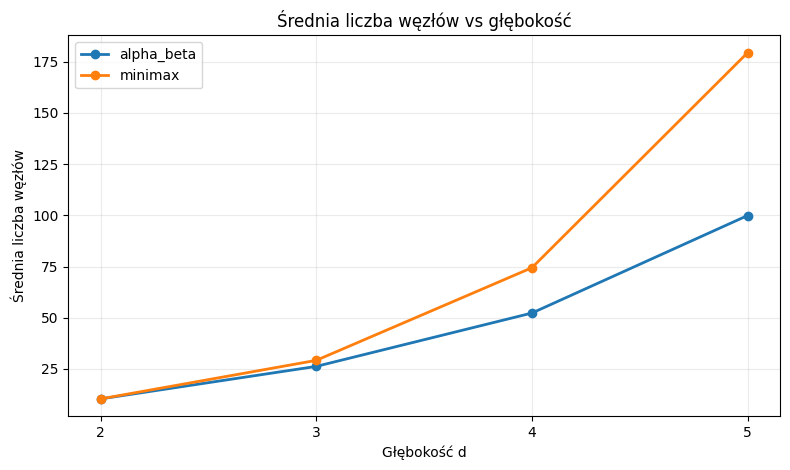

In [51]:
depths = sorted({r['depth'] for r in rows})
variants = sorted({r['variant'] for r in rows})

nodes_by_variant = {v: [] for v in variants}
for v in variants:
    indexed = {r['depth']: r['avg_nodes'] for r in rows if r['variant'] == v}
    nodes_by_variant[v] = [indexed[d] for d in depths]

plt.figure(figsize=(8, 4.8))
for v in variants:
    plt.plot(depths, nodes_by_variant[v], marker='o', linewidth=2, label=v)

plt.title('Średnia liczba węzłów vs głębokość')
plt.xlabel('Głębokość d')
plt.ylabel('Średnia liczba węzłów')
plt.xticks(depths)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

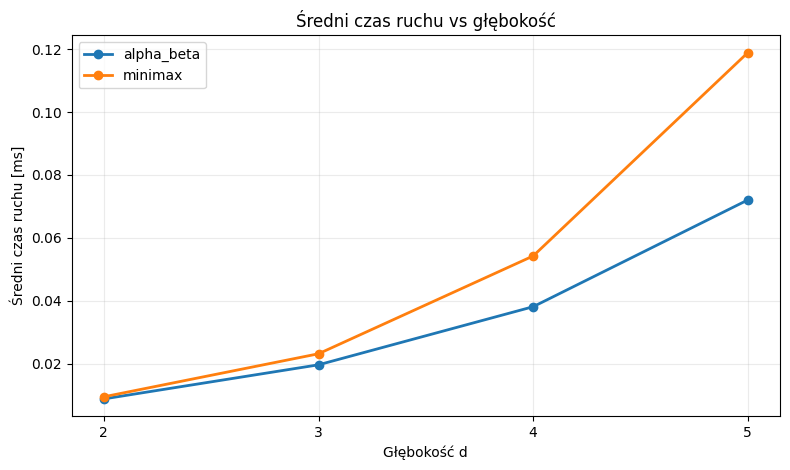

In [52]:
times_by_variant = {v: [] for v in variants}
for v in variants:
    indexed = {r['depth']: r['avg_time_ms'] for r in rows if r['variant'] == v}
    times_by_variant[v] = [indexed[d] for d in depths]

plt.figure(figsize=(8, 4.8))
for v in variants:
    plt.plot(depths, times_by_variant[v], marker='o', linewidth=2, label=v)

plt.title('Średni czas ruchu vs głębokość')
plt.xlabel('Głębokość d')
plt.ylabel('Średni czas ruchu [ms]')
plt.xticks(depths)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

## V. Wnioski: wpływ obcinania $\alpha-\beta$
1. Jakość decyzji
Skuteczność obu wariantów jest bardzo zbliżona (w tym 100% wygranych dla $d=5$), co potwierdza, że obcinanie $\alpha-\beta$ nie zmienia decyzji strategicznych, a jedynie optymalizuje przeszukiwanie.

2. Małe głębokości
Dla $d=2$ oba algorytmy odwiedzają średnio tyle samo węzłów (ok. 10,39), a czasy są niemal identyczne. Drzewo jest zbyt małe, aby obcinanie dawało duży efekt.

3. Większe głębokości
Dla $d=5$ różnica jest wyraźna: Minimax odwiedza średnio ok. 179 węzłów (ok. 0.13 ms), a Alpha-Beta ok. 100 węzłów (ok. 0.07 ms). Oznacza to redukcję liczby analizowanych stanowisk i czasu ruchu o prawie połowę.

4. Podsumowanie
Wyniki eksperymentu są zgodne z teorią: obcinanie $\alpha-\beta$ zachowuje jakość decyzji i znacząco poprawia wydajność wraz ze wzrostem głębokości przeszukiwania.
